In [1]:
MEMBER_NAME = "Welpwelawa"
IT_NUMBER = "IT25102510"
TASK = "Image Standardization"

print(MEMBER_NAME)
print(IT_NUMBER)
print(TASK)

Welpwelawa
IT25102510
Image Standardization


In [2]:
from google.colab import drive

drive.mount("/content/drive")

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [3]:
from pathlib import Path

possible_projects = []

for p in Path("/content/drive").rglob("Waste_Classification"):
    if p.is_dir():
        possible_projects.append(p)

print("Waste_Classification folders found:\n")

for p in possible_projects:
    print(p)

Waste_Classification folders found:

/content/drive/MyDrive/Waste_Classification
/content/drive/.shortcut-targets-by-id/1PoprMbg0JKQ7cGC9VyKmeTI1VK1Va65k/Waste_Classification


In [4]:
PROJECT_CANDIDATES = [
    p for p in Path("/content/drive").rglob("Waste_Classification")
    if p.is_dir()
]

if not PROJECT_CANDIDATES:
    raise FileNotFoundError(
        "Waste_Classification folder was not found in mounted Google Drive."
    )

PROJECT = PROJECT_CANDIDATES[0]

print("PROJECT:", PROJECT)

PROJECT: /content/drive/MyDrive/Waste_Classification


In [5]:
from pathlib import Path

RAW_DIR = PROJECT / "data" / "raw"
PROCESSED_DIR = PROJECT / "data" / "processed"
RESULTS_DIR = PROJECT / "results"
REPORT_DIR = PROJECT / "audit_reports"

EDA_DIR = RESULTS_DIR / "eda_visualizations"
OUTPUT_DIR = RESULTS_DIR / "outputs"

STAGE3_DIR = PROCESSED_DIR / "stage3_labels"
STAGE4_DIR = PROCESSED_DIR / "stage4_standardized"

for folder in [
    PROCESSED_DIR,
    RESULTS_DIR,
    REPORT_DIR,
    EDA_DIR,
    OUTPUT_DIR,
    STAGE4_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("PROJECT :", PROJECT)
print("INPUT   :", STAGE3_DIR)
print("OUTPUT  :", STAGE4_DIR)
print("OUTPUT REPORTS:", OUTPUT_DIR)
print("EDA     :", EDA_DIR)

PROJECT : /content/drive/MyDrive/Waste_Classification
INPUT   : /content/drive/MyDrive/Waste_Classification/data/processed/stage3_labels
OUTPUT  : /content/drive/MyDrive/Waste_Classification/data/processed/stage4_standardized
OUTPUT REPORTS: /content/drive/MyDrive/Waste_Classification/results/outputs
EDA     : /content/drive/MyDrive/Waste_Classification/results/eda_visualizations


In [6]:
assert STAGE3_DIR.exists(), (
    "Stage 3 dataset does not exist. "
    "Please get the completed Stage 3 handoff from Member 3."
)

print("Stage 3 exists.")

Stage 3 exists.


In [7]:
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".webp", ".bmp", ".gif",
    ".tif", ".tiff"
}

stage3_files = sorted([
    p for p in STAGE3_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
])

print("Stage 3 image count:", len(stage3_files))

Stage 3 image count: 2622


In [8]:
for item in sorted(STAGE3_DIR.iterdir()):
    print(item.name)

Hazardous
Non-Recyclable
Organic
Recyclable


In [9]:
!pip -q install pillow pandas numpy matplotlib

In [10]:
import os
import shutil
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = False

print("Libraries imported successfully.")

Libraries imported successfully.


File: /content/drive/MyDrive/Waste_Classification/data/processed/stage3_labels/Hazardous/batteries/1-s2.0-S0892687521004477-ga1.jpg
Size: (447, 200)
Width: 447
Height: 200
Mode: RGB
Format: JPEG


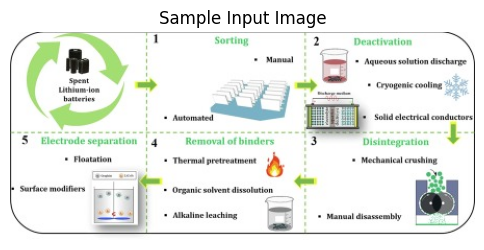

In [11]:
sample_path = stage3_files[0]

with Image.open(sample_path) as img:
    print("File:", sample_path)
    print("Size:", img.size)
    print("Width:", img.width)
    print("Height:", img.height)
    print("Mode:", img.mode)
    print("Format:", img.format)

    plt.figure(figsize=(6, 5))
    plt.imshow(img)
    plt.title("Sample Input Image")
    plt.axis("off")
    plt.show()

In [12]:
records = []

for index, input_path in enumerate(stage3_files, start=1):

    relative_path = input_path.relative_to(STAGE3_DIR)

    output_path = STAGE4_DIR / relative_path
    output_path.parent.mkdir(parents=True, exist_ok=True)

    try:
        with Image.open(input_path) as img:

            # Original information
            original_width, original_height = img.size
            original_mode = img.mode

            # Convert to RGB
            standardized = img.convert("RGB")

            # Resize to 224 × 224
            standardized = standardized.resize(
                (224, 224),
                Image.Resampling.LANCZOS
            )

            # Save standardized image
            standardized.save(output_path, quality=95)

            # Save audit information
            records.append({
                "relative_path": str(relative_path),
                "original_width": original_width,
                "original_height": original_height,
                "original_mode": original_mode,
                "new_width": standardized.width,
                "new_height": standardized.height,
                "new_mode": standardized.mode,
                "status": "STANDARDIZED"
            })

    except Exception as e:

        records.append({
            "relative_path": str(relative_path),
            "original_width": None,
            "original_height": None,
            "original_mode": None,
            "new_width": None,
            "new_height": None,
            "new_mode": None,
            "status": f"ERROR: {repr(e)}"
        })

    if index % 250 == 0:
        print(f"Processed {index} / {len(stage3_files)}")

standardization_df = pd.DataFrame(records)

print("\nStandardization complete.")
print(standardization_df["status"].value_counts())

Processed 250 / 2622


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Processed 500 / 2622


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Processed 750 / 2622


...

Processed 2000 / 2622


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Processed 2250 / 2622


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Processed 2500 / 2622

Standardization complete.
status
STANDARDIZED    2622
Name: count, dtype: int64


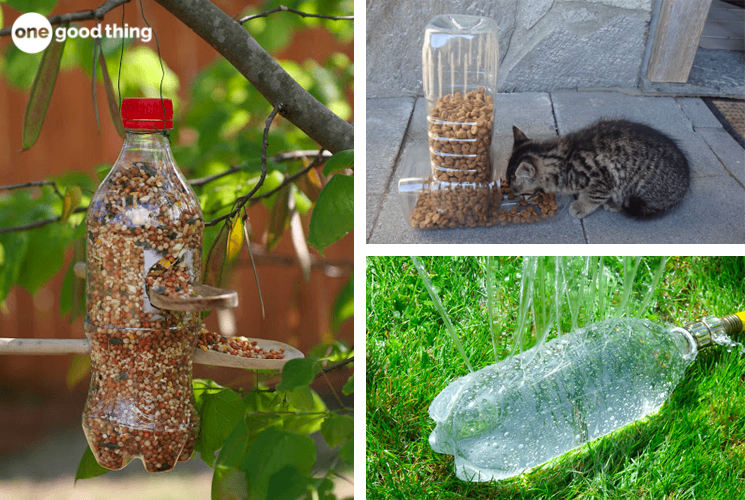

In [13]:
img.convert("RGB")

In [16]:
manifest_path = OUTPUT_DIR / "member4_standardization_manifest.csv"

standardization_df.to_csv(
    manifest_path,
    index=False
)

print("Manifest saved to:")
print(manifest_path)

Manifest saved to:
/content/drive/MyDrive/Waste_Classification/results/outputs/member4_standardization_manifest.csv


In [17]:
standardization_df["class"] = (
    standardization_df["relative_path"]
    .str.split("/")
    .str[0]
)

standardization_df = standardization_df[
    [
        "relative_path",
        "class",
        "original_width",
        "original_height",
        "original_mode",
        "new_width",
        "new_height",
        "new_mode",
        "status"
    ]
]

standardization_df.to_csv(
    manifest_path,
    index=False
)

display(standardization_df.head())

,relative_path,class,original_width,original_height,original_mode,new_width,new_height,new_mode,status
0,Hazardous/batteries/1-s2.0-S0892687521004477-g...,Hazardous,447,200,RGB,224,224,RGB,STANDARDIZED
1,Hazardous/batteries/1-s2.0-S2405829720304827-f...,Hazardous,245,245,RGB,224,224,RGB,STANDARDIZED
2,Hazardous/batteries/1-s2.0-S2666016421000268-g...,Hazardous,340,200,RGB,224,224,RGB,STANDARDIZED
3,Hazardous/batteries/12209_2020_236_Fig1_HTML.png,Hazardous,685,641,RGB,224,224,RGB,STANDARDIZED
4,Hazardous/batteries/12209_2020_236_Fig2_HTML.png,Hazardous,685,436,RGB,224,224,RGB,STANDARDIZED


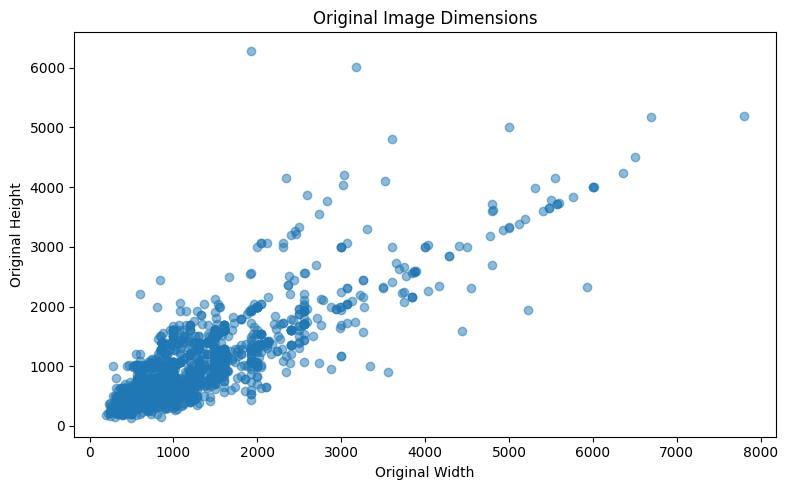

Saved: /content/drive/MyDrive/Waste_Classification/results/eda_visualizations/member4_original_dimensions.png


In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(
    standardization_df["original_width"],
    standardization_df["original_height"],
    alpha=0.5
)

plt.xlabel("Original Width")
plt.ylabel("Original Height")
plt.title("Original Image Dimensions")

plt.tight_layout()

before_dim_path = EDA_DIR / "member4_original_dimensions.png"

plt.savefig(
    before_dim_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", before_dim_path)

In [19]:
before_sizes = (
    standardization_df[
        ["original_width", "original_height"]
    ]
    .value_counts()
)

after_sizes = (
    standardization_df[
        ["new_width", "new_height"]
    ]
    .value_counts()
)

print("Most common original sizes:")
display(before_sizes.head(10))

print("\nStandardized sizes:")
display(after_sizes.head(10))

Most common original sizes:


original_width  original_height
1280            720                56
1300            956                34
1500            1101               33
1200            800                30
1000            1000               29
500             500                27
1200            1200               22
                628                21
800             534                21
1200            630                20
Name: count, dtype: int64


Standardized sizes:


,,count
new_width,new_height,
224,224,2622


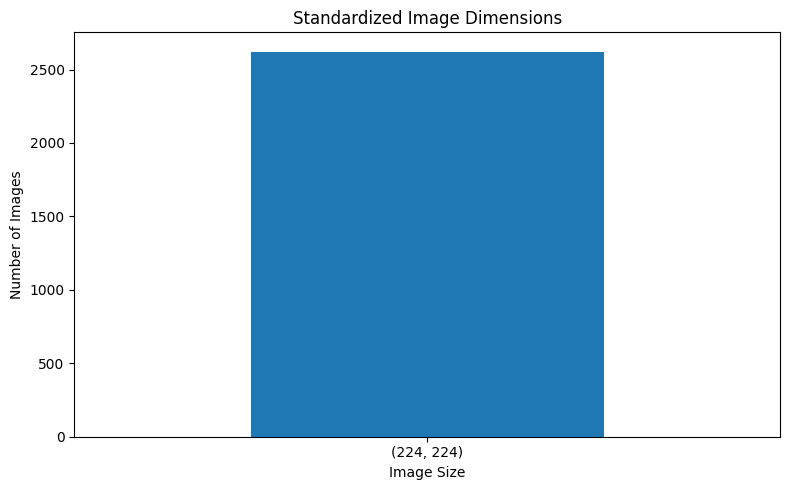

Saved: /content/drive/MyDrive/Waste_Classification/results/eda_visualizations/member4_standardized_dimensions.png


In [20]:
plt.figure(figsize=(8, 5))

after_counts = standardization_df.groupby(
    ["new_width", "new_height"]
).size()

after_counts.plot(kind="bar")

plt.title("Standardized Image Dimensions")
plt.xlabel("Image Size")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.tight_layout()

after_dim_path = EDA_DIR / "member4_standardized_dimensions.png"

plt.savefig(
    after_dim_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", after_dim_path)

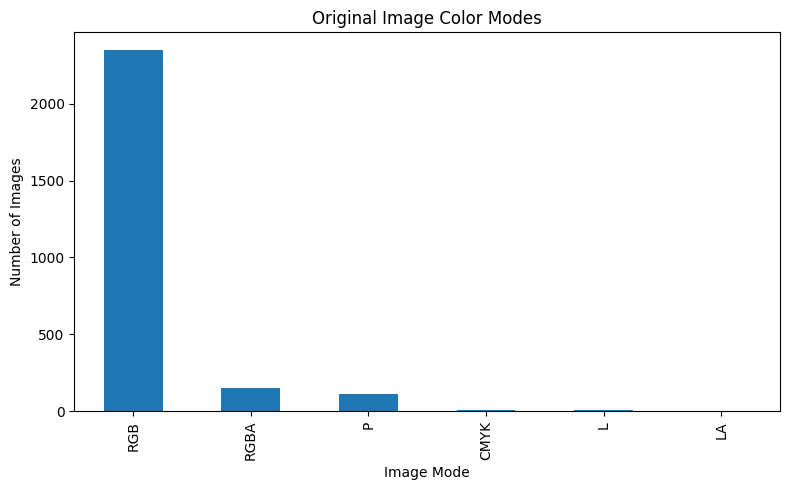

Saved: /content/drive/MyDrive/Waste_Classification/results/eda_visualizations/member4_original_modes.png


In [21]:
mode_counts = standardization_df["original_mode"].value_counts()

plt.figure(figsize=(8, 5))

mode_counts.plot(kind="bar")

plt.title("Original Image Color Modes")
plt.xlabel("Image Mode")
plt.ylabel("Number of Images")

plt.tight_layout()

mode_path = EDA_DIR / "member4_original_modes.png"

plt.savefig(
    mode_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", mode_path)

In [22]:
print(
    standardization_df["new_mode"]
    .value_counts()
)

new_mode
RGB    2622
Name: count, dtype: int64


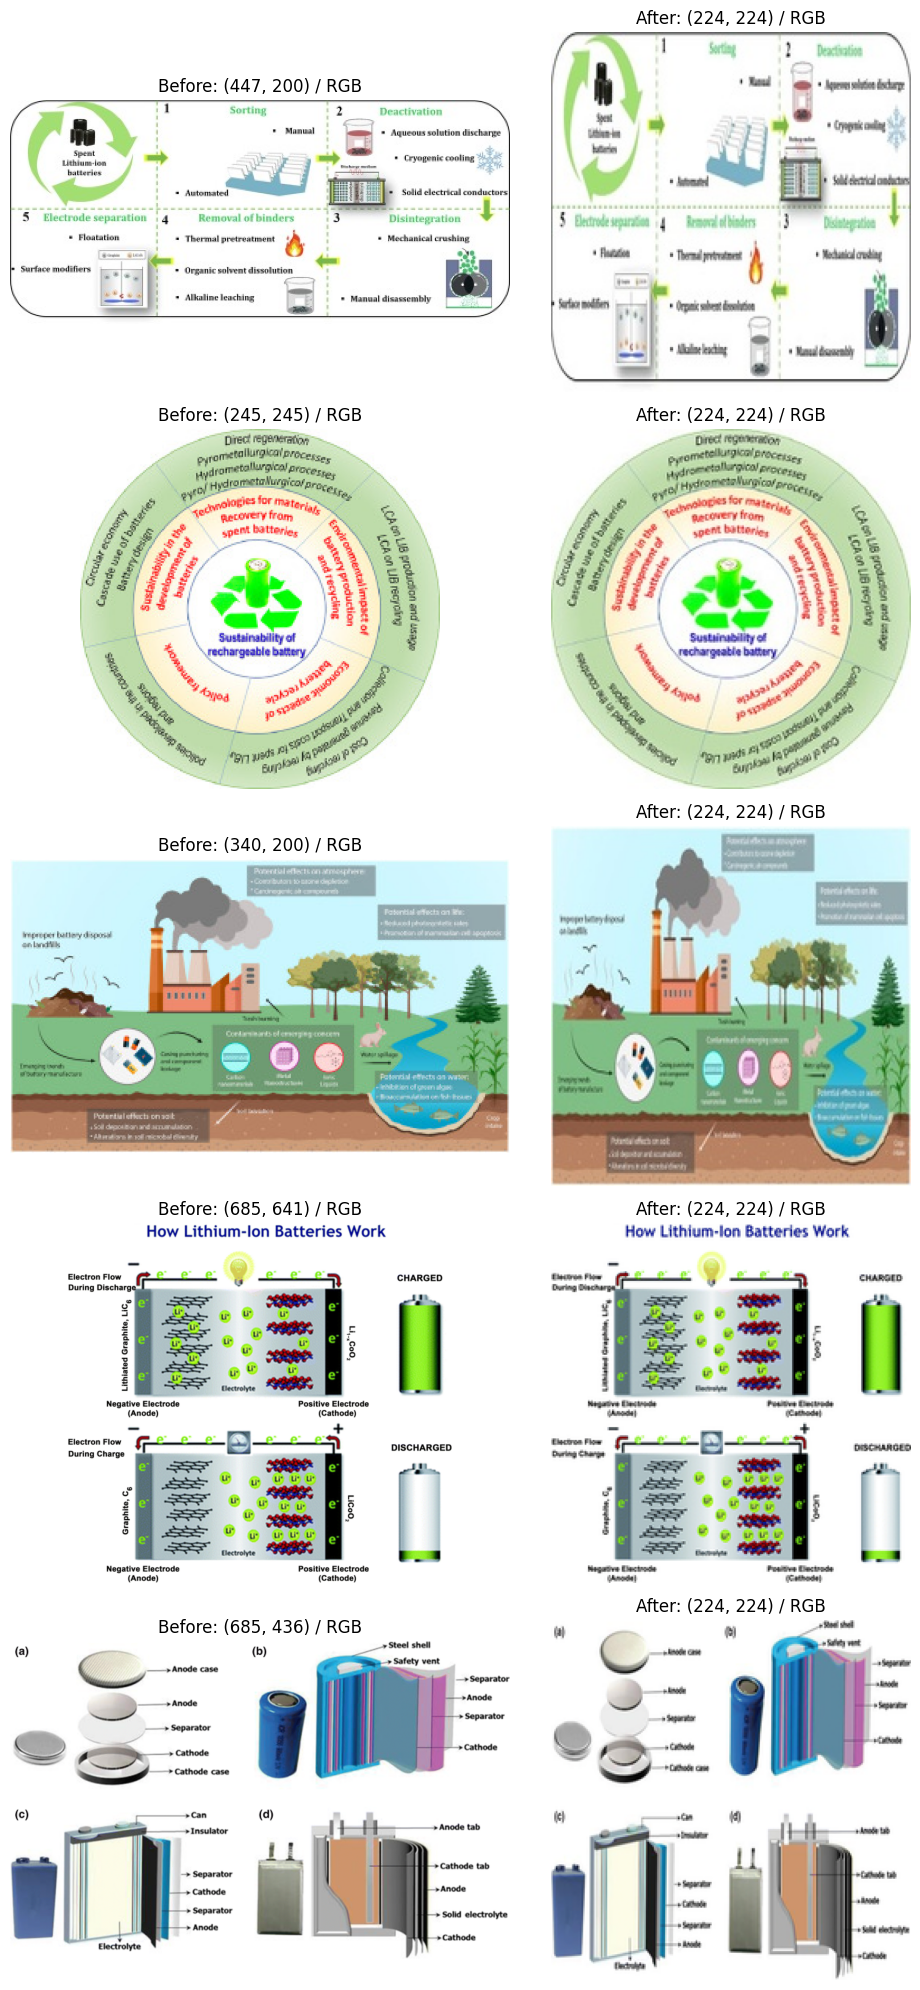

Saved: /content/drive/MyDrive/Waste_Classification/results/eda_visualizations/member4_before_after_examples.png


In [23]:
sample_paths = stage3_files[:5]

fig, axes = plt.subplots(
    len(sample_paths),
    2,
    figsize=(10, 4 * len(sample_paths))
)

for row, input_path in enumerate(sample_paths):

    output_path = STAGE4_DIR / input_path.relative_to(STAGE3_DIR)

    with Image.open(input_path) as original:
        with Image.open(output_path) as standardized:

            axes[row, 0].imshow(original)
            axes[row, 0].set_title(
                f"Before: {original.size} / {original.mode}"
            )
            axes[row, 0].axis("off")

            axes[row, 1].imshow(standardized)
            axes[row, 1].set_title(
                f"After: {standardized.size} / {standardized.mode}"
            )
            axes[row, 1].axis("off")

plt.tight_layout()

comparison_path = EDA_DIR / "member4_before_after_examples.png"

plt.savefig(
    comparison_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", comparison_path)

In [24]:
stage4_files = sorted([
    p for p in STAGE4_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
])

print("Stage 3 input images :", len(stage3_files))
print("Stage 4 output images:", len(stage4_files))

assert len(stage4_files) == len(stage3_files), (
    "Input/output image count mismatch."
)

print("Image count verification PASSED.")

Stage 3 input images : 2622
Stage 4 output images: 2622
Image count verification PASSED.


In [25]:
verification_records = []

for p in stage4_files:

    try:
        with Image.open(p) as img:

            verification_records.append({
                "file": str(p.relative_to(STAGE4_DIR)),
                "width": img.width,
                "height": img.height,
                "mode": img.mode,
                "valid": (
                    img.width == 224
                    and img.height == 224
                    and img.mode == "RGB"
                )
            })

    except Exception as e:

        verification_records.append({
            "file": str(p.relative_to(STAGE4_DIR)),
            "width": None,
            "height": None,
            "mode": None,
            "valid": False
        })

verification_df = pd.DataFrame(verification_records)

display(verification_df.head())

print("Invalid standardized images:",
      (~verification_df["valid"]).sum())

,file,width,height,mode,valid
0,Hazardous/batteries/1-s2.0-S0892687521004477-g...,224,224,RGB,True
1,Hazardous/batteries/1-s2.0-S2405829720304827-f...,224,224,RGB,True
2,Hazardous/batteries/1-s2.0-S2666016421000268-g...,224,224,RGB,True
3,Hazardous/batteries/12209_2020_236_Fig1_HTML.png,224,224,RGB,True
4,Hazardous/batteries/12209_2020_236_Fig2_HTML.png,224,224,RGB,True


Invalid standardized images: 13


In [27]:
assert verification_df["valid"].all(), (
    "Some standardized images are not RGB 224×224."
)

print("✓ ALL OUTPUT IMAGES ARE RGB")
print("✓ ALL OUTPUT IMAGES ARE 224×224")

AssertionError: Some standardized images are not RGB 224×224.

In [28]:
class_counts = (
    verification_df["file"]
    .str.split("/")
    .str[0]
    .value_counts()
    .sort_index()
)

print("Stage 4 class distribution:")
print(class_counts)

Stage 4 class distribution:
file
Hazardous         672
Non-Recyclable    637
Organic           663
Recyclable        650
Name: count, dtype: int64


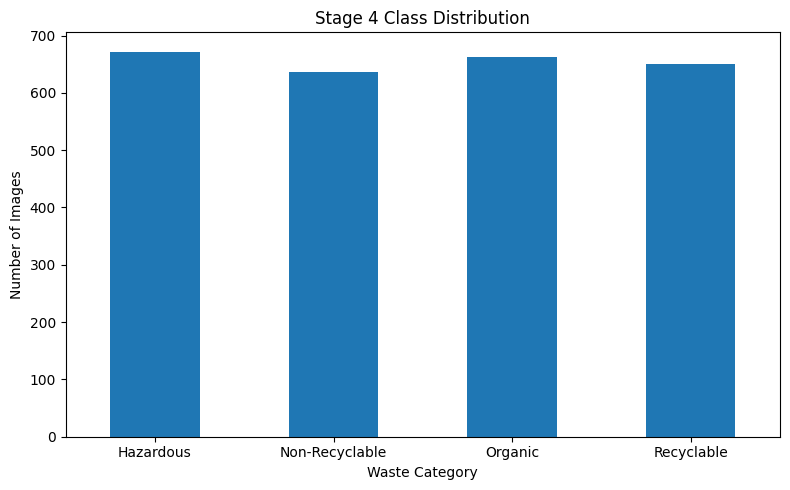

Saved: /content/drive/MyDrive/Waste_Classification/results/eda_visualizations/member4_class_distribution.png


In [29]:
plt.figure(figsize=(8, 5))

class_counts.plot(kind="bar")

plt.title("Stage 4 Class Distribution")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.tight_layout()

class_eda_path = EDA_DIR / "member4_class_distribution.png"

plt.savefig(
    class_eda_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", class_eda_path)

In [30]:
completion = {
    "member": MEMBER_NAME,
    "it_number": IT_NUMBER,
    "task": TASK,
    "status": "COMPLETED",
    "input_stage": "stage3_labels",
    "output_stage": "stage4_standardized",
    "input_image_count": len(stage3_files),
    "output_image_count": len(stage4_files),
    "target_size": [224, 224],
    "target_mode": "RGB",
    "next_step": "Hand off stage4_standardized to Member 5 for Pixel Normalization."
}

completion_path = (
    OUTPUT_DIR /
    "IT25102510_completion_record.json"
)

completion_path.write_text(
    json.dumps(completion, indent=2)
)

print("Completion record saved:")
print(completion_path)

Completion record saved:
/content/drive/MyDrive/Waste_Classification/results/outputs/IT25102510_completion_record.json


In [30]:
%cd /content

!git clone https://github.com/IT25102140/waste-classification-aiml.git

/content
fatal: destination path 'waste-classification-aiml' already exists and is not an empty directory.


In [40]:
%cd /content/waste-classification-aiml


/content/waste-classification-aiml


In [42]:
!git pull --rebase origin main

From https://github.com/IT25102140/waste-classification-aiml
 * branch            main       -> FETCH_HEAD
Already up to date.
